In [31]:
#importing the stuff that will be needed for the analysis
from sklearn.metrics import (recall_score, confusion_matrix, roc_auc_score, precision_score, f1_score,
                    accuracy_score, roc_curve, classification_report)
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [32]:
dataset_test = pd.read_csv('test.csv')
dataset_test 

,Unnamed: 0,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,female,male,other,current,ever,former,never,no info,not current
0,2,54,0,0,27.32,6.6,80,0,1,0,0,0,0,0,0,1,0
1,5,76,1,1,20.14,4.8,155,0,0,1,0,1,0,0,0,0,0
2,10,32,0,0,27.32,5.0,100,0,1,0,0,0,0,0,1,0,0
3,17,15,0,0,30.36,6.1,200,0,0,1,0,0,0,0,1,0,0
4,30,43,0,0,26.08,6.1,155,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19218,99962,38,0,0,27.63,4.0,145,0,0,1,0,0,0,0,1,0,0
19219,99980,61,0,0,30.11,6.2,240,1,1,0,0,1,0,0,0,0,0
19220,99988,23,0,0,17.87,5.8,100,0,1,0,0,0,0,0,1,0,0
19221,99992,22,0,0,29.65,6.0,80,0,0,1,0,1,0,0,0,0,0


In [33]:
dataset_training = pd.read_csv('train.csv') 
dataset_training

,Unnamed: 0,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,female,male,other,current,ever,former,never,no info,not current
0,63066,45,1,0,44.35,4.0,200,0,0,1,0,0,0,1,0,0,0
1,55713,45,0,1,29.95,6.0,158,0,0,1,0,1,0,0,0,0,0
2,76757,57,1,0,30.04,8.2,260,1,0,1,0,0,0,0,0,0,1
3,47140,80,0,0,24.29,6.2,158,0,1,0,0,0,0,0,0,0,1
4,48098,21,0,0,32.92,4.8,140,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76884,4327,50,0,0,35.41,4.8,126,0,0,1,0,0,0,0,1,0,0
76885,88698,24,0,0,24.79,6.0,155,0,1,0,0,0,0,0,1,0,0
76886,54442,60,0,0,37.79,6.5,159,1,0,1,0,0,0,1,0,0,0
76887,95902,12,0,0,27.32,6.0,145,0,1,0,0,0,0,0,0,1,0


In [34]:
#dropping irrelevant columns
dataset_training = dataset_training.drop(columns = ['Unnamed: 0', 'other']) 
dataset_test  = dataset_test.drop(columns = ['Unnamed: 0', 'other']) 

In [35]:
#scaling the data with the continuous and not the binary columns
binary_cols = [c for c in dataset_training.columns if set(pd.unique(dataset_training[c].dropna())) <= {0, 1}]
cont_cols   = [c for c in dataset_training.columns if c not in binary_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), cont_cols),
        ("keep_bin", "passthrough", binary_cols),])

train_scaled_array = preprocess.fit_transform(dataset_training) 
test_scaled_array = preprocess.transform(dataset_test)

new_cols = cont_cols + binary_cols  
train_scaled = pd.DataFrame(train_scaled_array, columns=new_cols, index=dataset_training.index)
test_scaled  = pd.DataFrame(test_scaled_array,  columns=new_cols, index=dataset_test.index)

In [36]:
train_scaled.head() 

,age,bmi,HbA1c_level,blood_glucose_level,hypertension,heart_disease,diabetes,female,male,current,ever,former,never,no info,not current
0,0.141014,2.521511,-1.429243,1.514969,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.141014,0.390141,0.435572,0.486562,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.674635,0.403462,2.486868,2.984121,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.697407,-0.447605,0.622053,0.486562,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.926226,0.829736,-0.683317,0.045817,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Experiment 1: Dropped HbA1c_level

Training X: 76889 rows.
Training Y: 76889 rows.

Confusion Matrix:
[[17338   167]
 [ 1010   708]]

                                0
Accuracy                 0.938771
Sensitivty               0.412107
Specificity              0.990460
AUC                      0.907897
Precision (No Diabetes)  0.944953
F1-Score (No Diabetes)   0.967172
Precision (Diabetes)     0.809143
F1-Score (Diabetes)      0.546086

              precision    recall  f1-score   support

 No Diabetes      0.945     0.990     0.967     17505
Yes Diabetes      0.809     0.412     0.546      1718

    accuracy                          0.939     19223
   macro avg      0.877     0.701     0.757     19223
weighted avg      0.933     0.939     0.930     19223



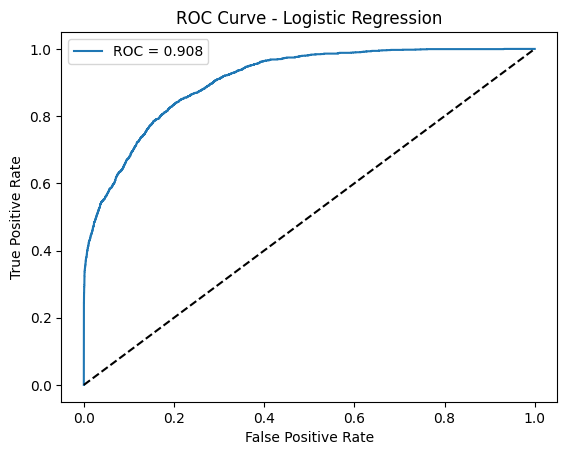

In [37]:
#set the train and test with the y test and train having the target variable of diabetes and the x test and train without it
X_train = train_scaled.drop(['diabetes','HbA1c_level'], axis = 1)
X_test  = test_scaled.drop(['diabetes','HbA1c_level'], axis = 1)
y_train = train_scaled['diabetes'] 
y_test  = test_scaled['diabetes']

print(f'Training X: {len(X_train)} rows.') 
print(f'Training Y: {len(y_train)} rows.')
print()

#using the logistic regression function to set the prediction
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)             
y_prob = lr.predict_proba(X_test)[:, 1] 

#doing the confusion matrix, classification report and ROC for metrics we can use for model comparison
accuracy = accuracy_score(y_test, y_pred) 
auc = roc_auc_score(y_test, y_prob)
sensitivity = recall_score(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivty': sensitivity,
    'Specificity': specificity,
    'AUC': auc,
    'Precision (No Diabetes)': precision_score(y_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test, y_pred, pos_label=1)}
print()

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_test, y_pred, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
plt.plot(fpr, tpr, label=f"ROC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show() 

Experiment 2: Dropped Diabetes only

Training X: 76889 rows.
Training Y: 76889 rows.

Confusion Matrix:
[[17337   168]
 [  613  1105]]


                                0
Accuracy                 0.959372
Sensitivty               0.643190
Specificity              0.990403
AUC                      0.962780
Precision (No Diabetes)  0.965850
F1-Score (No Diabetes)   0.977972
Precision (Diabetes)     0.868028
F1-Score (Diabetes)      0.738883

              precision    recall  f1-score   support

 No Diabetes      0.966     0.990     0.978     17505
Yes Diabetes      0.868     0.643     0.739      1718

    accuracy                          0.959     19223
   macro avg      0.917     0.817     0.858     19223
weighted avg      0.957     0.959     0.957     19223



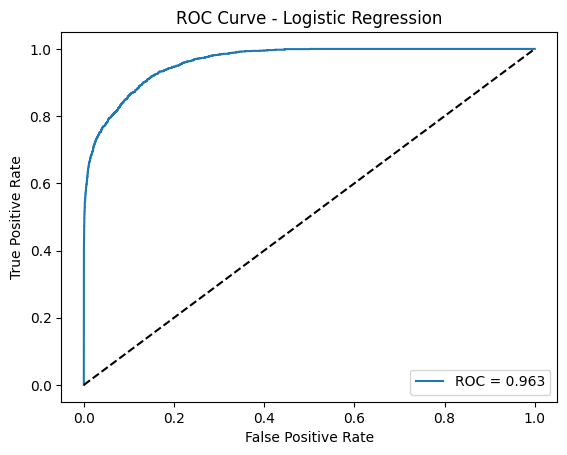

In [38]:
# #set the train and test with the y test and train having the target variable of diabetes and the x test and train without it
X_train = train_scaled.drop(['diabetes'], axis = 1)
X_test  = test_scaled.drop(['diabetes'], axis = 1)
y_train = train_scaled['diabetes'] 
y_test  = test_scaled['diabetes']

print(f'Training X: {len(X_train)} rows.') 
print(f'Training Y: {len(y_train)} rows.')
print()

#using the logistic regression function to set the prediction
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)             
y_prob = lr.predict_proba(X_test)[:, 1] 

#doing the confusion matrix, classification report and ROC for metrics we can use for model comparison
accuracy = accuracy_score(y_test, y_pred) 
auc = roc_auc_score(y_test, y_prob)
sensitivity = recall_score(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivty': sensitivity,
    'Specificity': specificity,
    'AUC': auc,
    'Precision (No Diabetes)': precision_score(y_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test, y_pred, pos_label=1)}
print()

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_test, y_pred, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
plt.plot(fpr, tpr, label=f"ROC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show() 

Experiment 3: Dropped smoking columns and hypertension

Training X: 76889 rows.
Training Y: 76889 rows.

Confusion Matrix:
[[17347   158]
 [  628  1090]]

                                0
Accuracy                 0.959111
Sensitivty               0.634459
Specificity              0.990974
AUC                      0.961592
Precision (No Diabetes)  0.965063
F1-Score (No Diabetes)   0.977847
Precision (Diabetes)     0.873397
F1-Score (Diabetes)      0.734997

              precision    recall  f1-score   support

 No Diabetes      0.965     0.991     0.978     17505
Yes Diabetes      0.873     0.634     0.735      1718

    accuracy                          0.959     19223
   macro avg      0.919     0.813     0.856     19223
weighted avg      0.957     0.959     0.956     19223



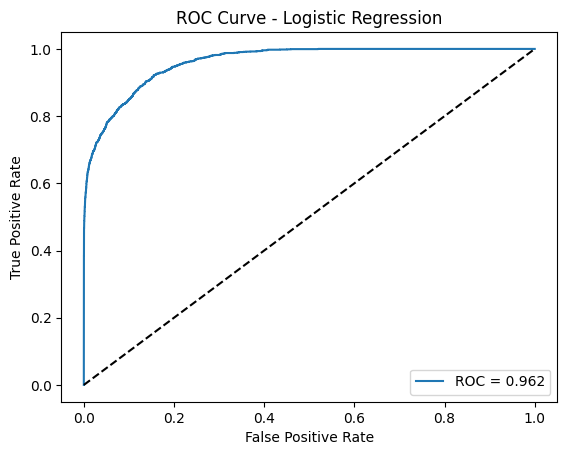

In [39]:
# #set the train and test with the y test and train having the target variable of diabetes and the x test and train without it
X_train = train_scaled.drop(['diabetes', 'no info', 'former', 'not current', 'never', 'ever', 'current', 'hypertension'], axis = 1)
X_test  = test_scaled.drop(['diabetes', 'no info', 'former', 'not current', 'never', 'ever', 'current', 'hypertension'], axis = 1)
y_train = train_scaled['diabetes'] 
y_test  = test_scaled['diabetes']

print(f'Training X: {len(X_train)} rows.') 
print(f'Training Y: {len(y_train)} rows.')
print()

#using the logistic regression function to set the prediction
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)             
y_prob = lr.predict_proba(X_test)[:, 1] 

#doing the confusion matrix, classification report and ROC for metrics we can use for model comparison
accuracy = accuracy_score(y_test, y_pred) 
auc = roc_auc_score(y_test, y_prob)
sensitivity = recall_score(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivty': sensitivity,
    'Specificity': specificity,
    'AUC': auc,
    'Precision (No Diabetes)': precision_score(y_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test, y_pred, pos_label=1)}
print()

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_test, y_pred, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
plt.plot(fpr, tpr, label=f"ROC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

Experiment 4: Dropped Hypertension

Training X: 76889 rows.
Training Y: 76889 rows.

Confusion Matrix:
[[17343   162]
 [  618  1100]]

                                0
Accuracy                 0.959424
Sensitivty               0.640279
Specificity              0.990746
AUC                      0.962173
Precision (No Diabetes)  0.965592
F1-Score (No Diabetes)   0.978007
Precision (Diabetes)     0.871632
F1-Score (Diabetes)      0.738255

              precision    recall  f1-score   support

 No Diabetes      0.966     0.991     0.978     17505
Yes Diabetes      0.872     0.640     0.738      1718

    accuracy                          0.959     19223
   macro avg      0.919     0.816     0.858     19223
weighted avg      0.957     0.959     0.957     19223



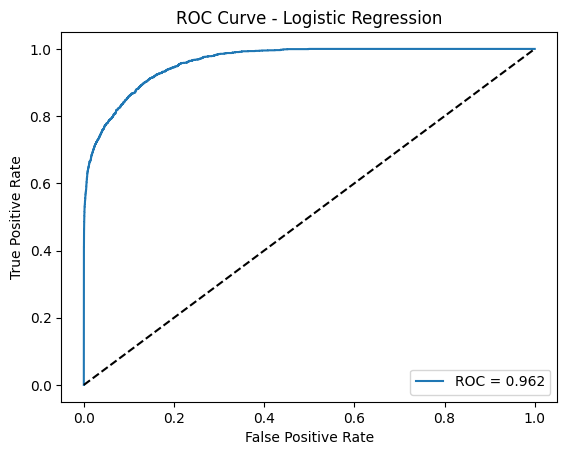

In [40]:
# #set the train and test with the y test and train having the target variable of diabetes and the x test and train without it
X_train = train_scaled.drop(['diabetes', 'hypertension'], axis = 1)
X_test  = test_scaled.drop(['diabetes', 'hypertension'], axis = 1)
y_train = train_scaled['diabetes'] 
y_test  = test_scaled['diabetes']

print(f'Training X: {len(X_train)} rows.') 
print(f'Training Y: {len(y_train)} rows.')
print()

#using the logistic regression function to set the prediction
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)             
y_prob = lr.predict_proba(X_test)[:, 1] 

#doing the confusion matrix, classification report and ROC for metrics we can use for model comparison
accuracy = accuracy_score(y_test, y_pred) 
auc = roc_auc_score(y_test, y_prob)
sensitivity = recall_score(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivty': sensitivity,
    'Specificity': specificity,
    'AUC': auc,
    'Precision (No Diabetes)': precision_score(y_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test, y_pred, pos_label=1)}
print()

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_test, y_pred, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
plt.plot(fpr, tpr, label=f"ROC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

Experiment 5: Dropped smoking columns and HbA1c_level

Training X: 76889 rows.
Training Y: 76889 rows.

Confusion Matrix:
[[17328   177]
 [ 1011   707]]

                                0
Accuracy                 0.938199
Sensitivty               0.411525
Specificity              0.989889
AUC                      0.906370
Precision (No Diabetes)  0.944872
F1-Score (No Diabetes)   0.966856
Precision (Diabetes)     0.799774
F1-Score (Diabetes)      0.543428

              precision    recall  f1-score   support

 No Diabetes      0.945     0.990     0.967     17505
Yes Diabetes      0.800     0.412     0.543      1718

    accuracy                          0.938     19223
   macro avg      0.872     0.701     0.755     19223
weighted avg      0.932     0.938     0.929     19223



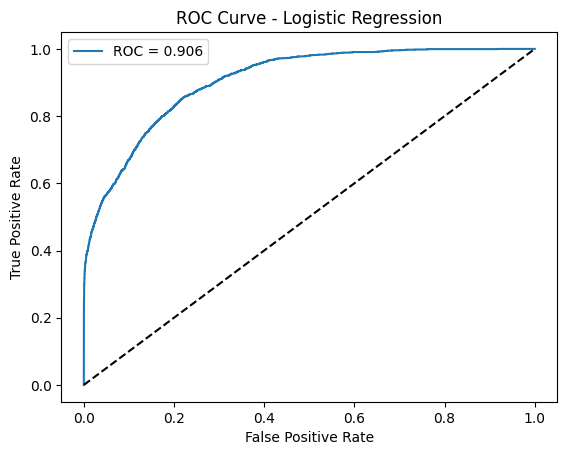

In [41]:
# #set the train and test with the y test and train having the target variable of diabetes and the x test and train without it
X_train = train_scaled.drop(['diabetes', 'no info', 'former', 'not current', 'never', 'ever', 'current', 'HbA1c_level'], axis = 1)
X_test  = test_scaled.drop(['diabetes', 'no info', 'former', 'not current', 'never', 'ever', 'current', 'HbA1c_level'], axis = 1)
y_train = train_scaled['diabetes'] 
y_test  = test_scaled['diabetes']

print(f'Training X: {len(X_train)} rows.') 
print(f'Training Y: {len(y_train)} rows.')
print()

#using the logistic regression function to set the prediction
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)             
y_prob = lr.predict_proba(X_test)[:, 1] 

#doing the confusion matrix, classification report and ROC for metrics we can use for model comparison
accuracy = accuracy_score(y_test, y_pred) 
auc = roc_auc_score(y_test, y_prob)
sensitivity = recall_score(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivty': sensitivity,
    'Specificity': specificity,
    'AUC': auc,
    'Precision (No Diabetes)': precision_score(y_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test, y_pred, pos_label=1)}
print()

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_test, y_pred, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
plt.plot(fpr, tpr, label=f"ROC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

Experiment 6: Dropped smoking columns and heart disease

Training X: 76889 rows.
Training Y: 76889 rows.

Confusion Matrix:
[[17338   167]
 [  620  1098]]

                                0
Accuracy                 0.959059
Sensitivty               0.639115
Specificity              0.990460
AUC                      0.961580
Precision (No Diabetes)  0.965475
F1-Score (No Diabetes)   0.977808
Precision (Diabetes)     0.867984
F1-Score (Diabetes)      0.736172

              precision    recall  f1-score   support

 No Diabetes      0.965     0.990     0.978     17505
Yes Diabetes      0.868     0.639     0.736      1718

    accuracy                          0.959     19223
   macro avg      0.917     0.815     0.857     19223
weighted avg      0.957     0.959     0.956     19223



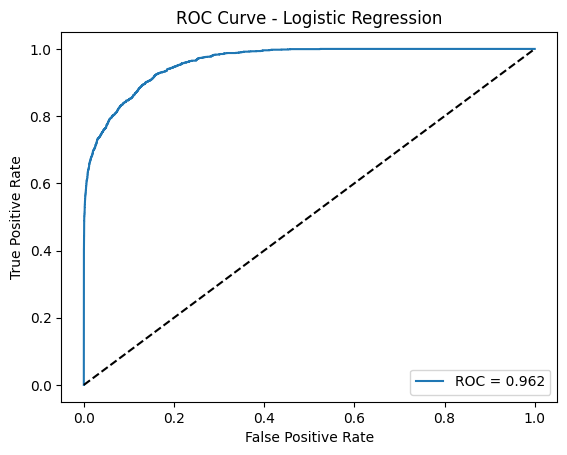

In [42]:
# #set the train and test with the y test and train having the target variable of diabetes and the x test and train without it
X_train = train_scaled.drop(['diabetes', 'no info', 'former', 'not current', 'never', 'ever', 'current', 'heart_disease'], axis = 1)
X_test  = test_scaled.drop(['diabetes', 'no info', 'former', 'not current', 'never', 'ever', 'current', 'heart_disease'], axis = 1)
y_train = train_scaled['diabetes'] 
y_test  = test_scaled['diabetes']

print(f'Training X: {len(X_train)} rows.')  
print(f'Training Y: {len(y_train)} rows.')
print()

#using the logistic regression function to set the prediction
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)             
y_prob = lr.predict_proba(X_test)[:, 1] 

#doing the confusion matrix, classification report and ROC for metrics we can use for model comparison
accuracy = accuracy_score(y_test, y_pred) 
auc = roc_auc_score(y_test, y_prob)
sensitivity = recall_score(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivty': sensitivity,
    'Specificity': specificity,
    'AUC': auc,
    'Precision (No Diabetes)': precision_score(y_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test, y_pred, pos_label=1)}
print()

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_test, y_pred, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
plt.plot(fpr, tpr, label=f"ROC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

Experiment 7: Dropped Heart Disease

Training X: 76889 rows.
Training Y: 76889 rows.

Confusion Matrix:
[[17341   164]
 [  615  1103]]

                                0
Accuracy                 0.959476
Sensitivty               0.642026
Specificity              0.990631
AUC                      0.962128
Precision (No Diabetes)  0.965750
F1-Score (No Diabetes)   0.978032
Precision (Diabetes)     0.870560
F1-Score (Diabetes)      0.739028

              precision    recall  f1-score   support

 No Diabetes      0.966     0.991     0.978     17505
Yes Diabetes      0.871     0.642     0.739      1718

    accuracy                          0.959     19223
   macro avg      0.918     0.816     0.859     19223
weighted avg      0.957     0.959     0.957     19223



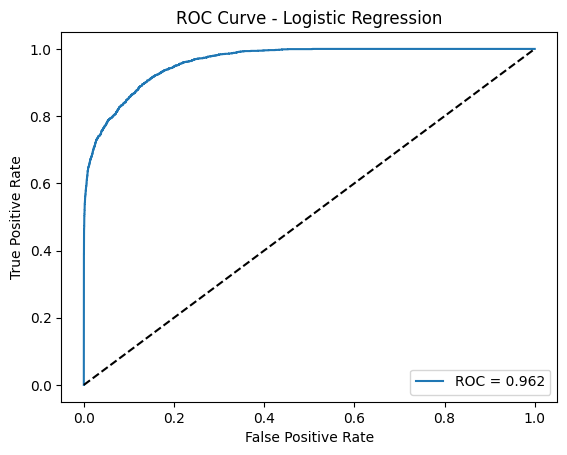

In [43]:
# #set the train and test with the y test and train having the target variable of diabetes and the x test and train without it
X_train = train_scaled.drop(['diabetes', 'heart_disease'], axis = 1)
X_test  = test_scaled.drop(['diabetes', 'heart_disease'], axis = 1)
y_train = train_scaled['diabetes'] 
y_test  = test_scaled['diabetes']

print(f'Training X: {len(X_train)} rows.')  
print(f'Training Y: {len(y_train)} rows.')
print()

#using the logistic regression function to set the prediction
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)             
y_prob = lr.predict_proba(X_test)[:, 1] 

#doing the confusion matrix, classification report and ROC for metrics we can use for model comparison
accuracy = accuracy_score(y_test, y_pred) 
auc = roc_auc_score(y_test, y_prob)
sensitivity = recall_score(y_test, y_pred)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivty': sensitivity,
    'Specificity': specificity,
    'AUC': auc,
    'Precision (No Diabetes)': precision_score(y_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test, y_pred, pos_label=1)}
print()

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_test, y_pred, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
plt.plot(fpr, tpr, label=f"ROC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()